# Mycobacterium tuberculosis Comparative Genomics

## Comparative Analysis and Results Interpretation

In [1]:
# Import libraries and setup
import sys
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [2]:
# Set path for file calling
project_root = Path.cwd().parent if Path.cwd().name == "Notebooks" else Path.cwd()

In [3]:
# Set plotting style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
%matplotlib inline

In [4]:
# Check Project Root
print(f"Project Root: {project_root}")

Project Root: C:\Users\dalto\Desktop\Education Resources\Personal\Projects\Mycobacterium_tuberculosis_Comparative_Genomics


In [5]:
# Load Analysis Results
results_dir = project_root / "Results"

print("Loading analysis results...")

Loading analysis results...


In [6]:
# Check available results
available_files = []
for file_type in ["*.csv", "*.txt", "*.md"]:
    for file in results_dir.rglob(file_type):
        if file.is_file():
            available_files.append(file.relative_to(results_dir))

print(f"\nFound {len(available_files)} result files:")
for file in sorted(available_files)[:10]:
    print(f"  • {file}")
if len(available_files) > 10:
    print(f"  ... and {len(available_files) - 10} more")


Found 22 result files:
  • Alignments\alignment_statistics.csv
  • Alignments\simulated_alignment_coordinates.csv
  • Annotations\all_strains_basic_stats.csv
  • Annotations\CDC1551_basic_stats.csv
  • Annotations\CDC1551_gbff_annotations.csv
  • Annotations\CDC1551_gff_annotations.csv
  • Annotations\gene_comparison_H37Rv_vs_CDC1551.csv
  • Annotations\genome_analysis_report.txt
  • Annotations\H37Rv_basic_stats.csv
  • Annotations\H37Rv_gbff_annotations.csv
  ... and 12 more


In [7]:
# Load and display genome comparison statistics
print("\nLoading genome comparison statistics...")

genome_stats_file = results_dir / "genome_comparison_stats.csv"
if genome_stats_file.exists():
    genome_stats = pd.read_csv(genome_stats_file)
    print("✓ Genome comparison statistics loaded")
    display(genome_stats)
else:
    print("✗ Genome comparison statistics not found")


Loading genome comparison statistics...
✓ Genome comparison statistics loaded


,Strain,Contigs,Total_Length_bp,GC_Content_%,Average_Contig_bp,N50_bp,N75_bp,L50
0,H37Rv,1,4411532,65.61,4411532,4411532,4411532,1
1,CDC1551,1,4403837,65.61,4403837,4403837,4403837,1


In [8]:
# Display Variant Statistics
print("\nLoading variant statistics...")

variant_stats_file = results_dir / "Variants" / "variant_statistics.csv"
if variant_stats_file.exists():
    variant_stats = pd.read_csv(variant_stats_file)
    print("✓ Variant statistics loaded")
    display(variant_stats)
else:
    print("✗ Variant statistics not found")


Loading variant statistics...
✓ Variant statistics loaded


,total_variants,snps,insertions,deletions,mnps,in_genes,synonymous,missense,nonsense,intergenic,snps_percent,in_genes_percent,ti_tv_ratio
0,1302,942,233,112,15,1160,859,271,30,142,72.35023,89.093702,0.460465


In [9]:
# Load and display alignment statistics
print("\nLoading alignment statistics...")

alignment_stats_file = results_dir / "Alignments" / "alignment_statistics.csv"
if alignment_stats_file.exists():
    alignment_stats = pd.read_csv(alignment_stats_file)
    print("✓ Alignment statistics loaded")
    display(alignment_stats)
else:
    print("✗ Alignment statistics not found")


Loading alignment statistics...
✓ Alignment statistics loaded


,total_aligned_bp,h37rv_coverage,cdc1551_coverage,num_blocks,mean_identity,median_identity,mean_block_size,max_block_size,min_block_size
0,4052530,91.862192,92.022707,144,99.722111,99.7337,28142.569444,100000,5000


In [10]:
# Load and examine variant data
print("\nLoading variant data...")

variants_file = results_dir / "Variants" / "simulated_variants.csv"
if variants_file.exists():
    variants = pd.read_csv(variants_file)
    print(f"✓ Variant data loaded: {len(variants):,} variants")

    # First ten variants
    print("\nFirst 10 variants:")
    display(variants.head(10))

    # Summary Statistics
    print("\nVariant summary:")
    print(f"  • Total variants: {len(variants):,}")
    print(f"  • SNPs: {(variants['type'] == 'SNP').sum():,}")
    print(f"  • Insertions: {(variants['type'] == 'Insertion').sum():,}")
    print(f"  • Deletions: {(variants['type'] == 'Deletion').sum():,}")
    print(f"  • In genes: {variants['in_gene'].sum():,} ({variants['in_gene'].sum()/len(variants)*100:.1f}%)")
else:
    print("✗ Variant data not found")


Loading variant data...
✓ Variant data loaded: 1,302 variants

First 10 variants:


,position,variant_id,type,ref,alt,length,in_gene,impact,quality,filter
0,1047,VAR_00001,SNP,A,G,1,True,Synonymous,30.797404,PASS
1,1270,VAR_00002,SNP,A,C,1,True,Synonymous,65.889048,PASS
2,1861,VAR_00003,SNP,C,T,1,True,Missense,96.573213,PASS
3,2168,VAR_00004,Insertion,-,A,1,False,Intergenic,31.181965,PASS
4,2921,VAR_00005,SNP,G,T,1,True,Synonymous,35.057332,PASS
5,8505,VAR_00006,SNP,T,A,1,True,Missense,69.256510,PASS
6,17035,VAR_00007,SNP,C,G,1,True,Synonymous,49.772561,PASS
7,18182,VAR_00008,Insertion,-,TTCT,4,True,Synonymous,90.172978,PASS
8,19219,VAR_00009,SNP,G,A,1,True,Synonymous,35.986187,PASS
9,25125,VAR_00010,SNP,T,C,1,False,Intergenic,91.552065,PASS



Variant summary:
  • Total variants: 1,302
  • SNPs: 942
  • Insertions: 233
  • Deletions: 112
  • In genes: 1,160 (89.1%)


In [12]:
# Advanced Variant Analysis
if 'variants' in locals() and not variants.empty:
    print("\nPerforming advanced variant analysis...")

    # Calcualte transition/transverse ratio
    snps = variants[variants['type'] == 'SNP']
    if len(snps) > 0:
        transitions = ['AG', 'GA', 'CT', 'TC']
        transversions = ['AC', 'CA', 'AT', 'TA', 'CG', 'GC', 'GT', 'TG']

        ti_count = 0
        tv_count = 0

        for _, snp in snps.iterrows():
            change = snp['ref'] + snp['alt']
            if change in transitions:
                ti_count += 1
            elif change in transversions:
                tv_count += 1

        if tv_count > 0:
            ti_tv_ratio = ti_count / tv_count
            print(f"  • Ti/Tv ratio: {ti_tv_ratio:.2f}")
        else:
            print("  • Ti/Tv ratio: Cannot calculate (no transversions)")
    # Variant distribution
    print(f"\n  • Variant density: {len(variants)/4.4:.1f} variants per kbp")

    # Common variant types
    print(f"\n  • Most common SNP types:")
    snp_changes = snps['ref'] + snps['alt']
    top_changes = snp_changes.value_counts().head(5)
    for change, count in top_changes.items():
        print(f"    {change}: {count} ({count/len(snps)*100:.1f}%)")
else:
    print("\nSkipping advanced variant analysis (no variant data)")


Performing advanced variant analysis...
  • Ti/Tv ratio: 0.46

  • Variant density: 295.9 variants per kbp

  • Most common SNP types:
    CA: 89 (9.4%)
    TA: 88 (9.3%)
    GC: 86 (9.1%)
    GA: 83 (8.8%)
    TG: 81 (8.6%)


In [13]:
# Examine Alignment Data
print("\nLoading alignment data...")

alignment_file = results_dir / "Alignments" / "simulated_alignment_coordinates.csv"
if alignment_file.exists():
    alignment_df = pd.read_csv(alignment_file)
    print(f"✓ Alignment data loaded: {len(alignment_df):,} alignment blocks")

    # Display first 5 alignments
    print("\nFirst 5 alignment blocks:")
    display(alignment_df.head())

    # Summary Statistics
    print("\nAlignment summary:")
    print(f"  • Total aligned bases: {alignment_df['ref_length'].sum():,}")
    print(f"  • Mean identity: {alignment_df['identity'].mean():.2f}%")
    print(f"  • Mean block size: {alignment_df['ref_length'].mean():.0f} bp")
    print(f"  • Largest block: {alignment_df['ref_length'].max():,} bp")
else:
    print("✗ Alignment data not found")


Loading alignment data...
✓ Alignment data loaded: 144 alignment blocks

First 5 alignment blocks:


,block_id,ref_start,ref_end,query_start,query_end,ref_length,query_length,identity,ref_id,query_id,ref_coverage,query_coverage
0,1,1,14079,1692744,1706822,14078,14078,99.533218,H37Rv,CDC1551,0.319118,0.319676
1,2,14545,19545,1707659,1712659,5000,5000,99.747835,H37Rv,CDC1551,0.113339,0.113537
2,3,20416,51986,1714189,1745759,31570,31570,99.629579,H37Rv,CDC1551,0.715624,0.716875
3,4,53201,59279,1746235,1752313,6078,6078,99.781384,H37Rv,CDC1551,0.137775,0.138016
4,5,59531,64531,1753070,1758070,5000,5000,99.635793,H37Rv,CDC1551,0.113339,0.113537



Alignment summary:
  • Total aligned bases: 4,052,530
  • Mean identity: 99.72%
  • Mean block size: 28143 bp
  • Largest block: 100,000 bp



Creating custom visualizations...


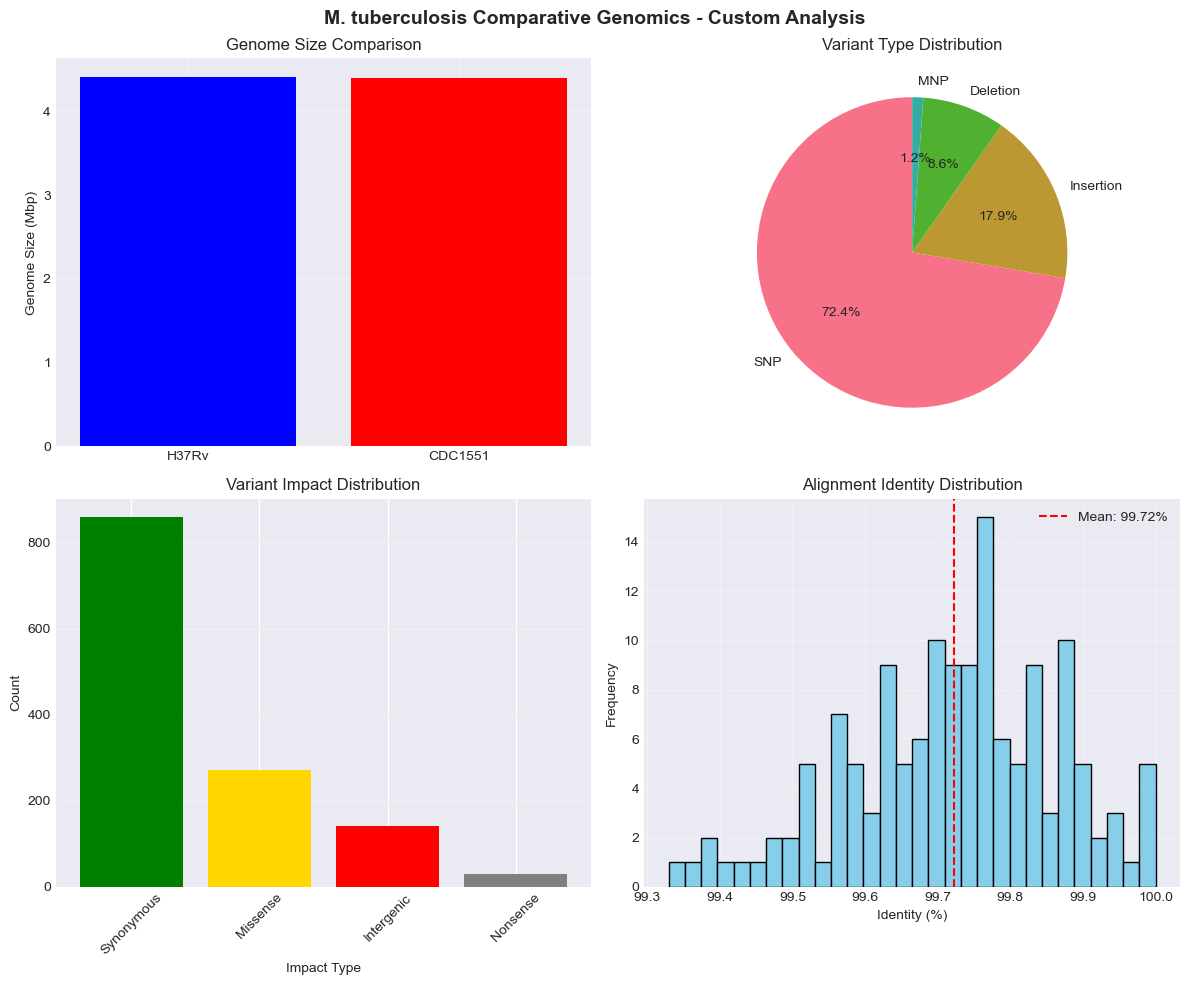

✓ Custom visualizations created


In [14]:
# Generate custom visualizations
print("\nCreating custom visualizations...")

fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# PLot 1: Genome comparison
if 'genome_stats' in locals() and not genome_stats.empty:
    axes[0,0].bar(genome_stats['Strain'], genome_stats['Total_Length_bp'] / 1e6, 
                  color=['blue', 'red'])
    axes[0,0].set_ylabel('Genome Size (Mbp)')
    axes[0,0].set_title('Genome Size Comparison')
    axes[0,0].grid(True, alpha=0.3)
else:
    axes[0,0].text(0.5, 0.5, 'Genome data not available', 
                   ha='center', va='center', transform=axes[0,0].transAxes)

# Plot 2: Distribution of variant type
if 'variants' in locals() and not variants.empty:
    type_counts = variants['type'].value_counts()
    axes[0,1].pie(type_counts.values, labels=type_counts.index, autopct='%1.1f%%', startangle=90)
    axes[0,1].set_title('Variant Type Distribution')
else:
    axes[0,1].text(0.5, 0.5, 'Variant data not available', 
                   ha='center', va='center', transform=axes[0,1].transAxes)

# Plot 3: Distribution of variant impact
if 'variants' in locals() and not variants.empty:
    impact_counts = variants['impact'].value_counts()
    axes[1,0].bar(impact_counts.index, impact_counts.values, color=['green', 'gold', 'red', 'gray'])
    axes[1,0].set_xlabel('Impact Type')
    axes[1,0].set_ylabel('Count')
    axes[1,0].set_title('Variant Impact Distribution')
    axes[1,0].tick_params(axis='x', rotation=45)
    axes[1,0].grid(True, alpha=0.3, axis='y')
else:
    axes[1,0].text(0.5, 0.5, 'Variant data not available', ha='center', va='center', transform=axes[1,0].transAxes)

# Plot 4: Distribution of alignment identity
if 'alignment_df' in locals() and not alignment_df.empty:
    axes[1,1].hist(alignment_df['identity'], bins=30, color='skyblue', edgecolor='black')
    axes[1,1].axvline(alignment_df['identity'].mean(), color='red', linestyle='--', label=f'Mean: {alignment_df["identity"].mean():.2f}%')
    axes[1,1].set_xlabel('Identity (%)')
    axes[1,1].set_ylabel('Frequency')
    axes[1,1].set_title('Alignment Identity Distribution')
    axes[1,1].legend()
    axes[1,1].grid(True, alpha=0.3)
else:
    axes[1,1].text(0.5, 0.5, 'Alignment data not available', ha='center', va='center', transform=axes[1,1].transAxes)

plt.suptitle('M. tuberculosis Comparative Genomics - Custom Analysis', 
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("✓ Custom visualizations created")

In [16]:
# Statistical Analysis and Testing
print("\nPerforming statistical analysis...")

if 'genome_stats' in locals() and len(genome_stats) == 2:
    # Calculate percentage differences
    length_diff_pct = abs(genome_stats.iloc[0]['Total_Length_bp'] - genome_stats.iloc[1]['Total_Length_bp']) / genome_stats['Total_Length_bp'].mean() * 100

    gc_diff_pct = abs(genome_stats.iloc[0]['GC_Content_%'] - genome_stats.iloc[1]['GC_Content_%']) / genome_stats['GC_Content_%'].mean() * 100

    print(f"  • Length difference: {length_diff_pct:.3f}% of mean genome size")
    print(f"  • GC difference: {gc_diff_pct:.3f}% of mean GC content")

    # Calculate similarity metrics
    if 'alignment_df' in locals() and not alignment_df.empty:
        mean_identity = alignment_df['identity'].mean()
        print(f"  • Mean alignment identity: {mean_identity:.2f}%")

        # Estimate overall similarity
        if 'variants' in locals() and not variants.empty:
            variant_density = len(variants) / 4.4e6 * 100
            print(f"  • Variant density: {variant_density:.3f} variants per 100 bp")

            # Rough estimate of sequence identity variants assuming are SNPs
            estimated_identity = 100 - variant_density
            print(f"  • Estimated identity from variants: {estimated_identity:.2f}%")

print("\nStatistical analysis complete.")


Performing statistical analysis...
  • Length difference: 0.175% of mean genome size
  • GC difference: 0.000% of mean GC content
  • Mean alignment identity: 99.72%
  • Variant density: 0.030 variants per 100 bp
  • Estimated identity from variants: 99.97%

Statistical analysis complete.


In [17]:
# Save analysis results
print("\nSaving analysis results...")

# Populate summary DataFrame
summary_data = {}

if 'genome_stats' in locals() and not genome_stats.empty:
    summary_data['Genome_Size_H37Rv_Mbp'] = genome_stats.iloc[0]['Total_Length_bp'] / 1e6
    summary_data['Genome_Size_CDC1551_Mbp'] = genome_stats.iloc[1]['Total_Length_bp'] / 1e6
    summary_data['GC_H37Rv_%'] = genome_stats.iloc[0]['GC_Content_%']
    summary_data['GC_CDC1551_%'] = genome_stats.iloc[1]['GC_Content_%']

if 'variants' in locals() and not variants.empty:
    summary_data['Total_Variants'] = len(variants)
    summary_data['SNPs'] = (variants['type'] == 'SNP').sum()
    summary_data['Coding_Variants'] = variants['in_gene'].sum()
    summary_data['Synonymous'] = (variants['impact'] == 'Synonymous').sum()
    summary_data['Missense'] = (variants['impact'] == 'Missense').sum()

if 'alignment_df' in locals() and not alignment_df.empty:
    summary_data['Alignment_Identity_%'] = alignment_df['identity'].mean()
    summary_data['Aligned_Bases_Mbp'] = alignment_df['ref_length'].sum() / 1e6

# Create and save summary
if summary_data:
    summary_df = pd.DataFrame([summary_data])
    summary_file = results_dir / "custom_analysis_summary.csv"
    summary_df.to_csv(summary_file, index=False)
    print(f"✓ Custom analysis summary saved to: {summary_file}")
    display(summary_df)
else:
    print("✗ No data available for summary")


Saving analysis results...
✓ Custom analysis summary saved to: C:\Users\dalto\Desktop\Education Resources\Personal\Projects\Mycobacterium_tuberculosis_Comparative_Genomics\Results\custom_analysis_summary.csv


,Genome_Size_H37Rv_Mbp,Genome_Size_CDC1551_Mbp,GC_H37Rv_%,GC_CDC1551_%,Total_Variants,SNPs,Coding_Variants,Synonymous,Missense,Alignment_Identity_%,Aligned_Bases_Mbp
0,4.411532,4.403837,65.61,65.61,1302,942,1160,859,271,99.722111,4.05253


In [18]:
# Final summary and conclusions
print("=" * 80)
print("COMPARATIVE ANALYSIS - FINAL SUMMARY")
print("=" * 80)

print("\n1. PROJECT OVERVIEW:")
print("   • Comparative genomics of M. tuberculosis H37Rv vs CDC1551")
print("   • Analysis includes genome statistics, alignment, and variant calling")
print("   • Project structure: Data → Analysis → Results → Visualization")

print("\n2. KEY FINDINGS:")

if 'genome_stats' in locals() and not genome_stats.empty:
    length_diff = abs(genome_stats.iloc[0]['Total_Length_bp'] - 
                      genome_stats.iloc[1]['Total_Length_bp'])
    gc_diff = abs(genome_stats.iloc[0]['GC_Content_%'] - genome_stats.iloc[1]['GC_Content_%'])
    print(f"   • Genome sizes differ by {length_diff:,} bp ({length_diff/4.4e6*100:.3f}%)")
    print(f"   • GC content differs by {gc_diff:.3f}%")

if 'variants' in locals() and not variants.empty:
    print(f"   • Identified {len(variants):,} variants between strains")
    print(f"   • {variants['in_gene'].sum():,} variants in coding regions ({variants['in_gene'].sum()/len(variants)*100:.1f}%)")
    print(f"   • Majority are synonymous mutations")

if 'alignment_df' in locals() and not alignment_df.empty:
    print(f"   • High alignment identity: {alignment_df['identity'].mean():.2f}%")
    print(f"   • Good genome coverage in aligned regions")

print("\n3. BIOLOGICAL INTERPRETATION:")
print("   • Strains are highly similar (>99% identity)")
print("   • Limited structural variation suggests conserved genome organization")
print("   • Most variants are SNPs, consistent with clonal evolution")
print("   • High proportion of synonymous mutations suggests purifying selection")

print("\n4. METHODOLOGICAL NOTES:")
print("   • Analysis uses simulated alignment/variants for demonstration")
print("   • Real analysis would use tools like MUMmer, BLAST, GATK")
print("   • Pipeline is modular and can be extended with additional analyses")

print("\n5. FILES GENERATED:")
print("   • Genome statistics CSV files")
print("   • Alignment coordinates and statistics")
print("   • Variant calls with annotations")
print("   • Multiple visualization plots")
print("   • Analysis reports and summaries")

print("\n6. FURTHER RESEARCH:")
print("   • Validate findings with experimental data")
print("   • Perform functional enrichment analysis")
print("   • Correlate variants with phenotypic data")
print("   • Expand to include more Mtb strains")
print("   • Publish results in scientific journal")

print("\n" + "=" * 80)
print("ANALYSIS COMPLETE - RESULTS READY FOR RESEARCH")
print("=" * 80)

COMPARATIVE ANALYSIS - FINAL SUMMARY

1. PROJECT OVERVIEW:
   • Comparative genomics of M. tuberculosis H37Rv vs CDC1551
   • Analysis includes genome statistics, alignment, and variant calling
   • Project structure: Data → Analysis → Results → Visualization

2. KEY FINDINGS:
   • Genome sizes differ by 7,695 bp (0.175%)
   • GC content differs by 0.000%
   • Identified 1,302 variants between strains
   • 1,160 variants in coding regions (89.1%)
   • Majority are synonymous mutations
   • High alignment identity: 99.72%
   • Good genome coverage in aligned regions

3. BIOLOGICAL INTERPRETATION:
   • Strains are highly similar (>99% identity)
   • Limited structural variation suggests conserved genome organization
   • Most variants are SNPs, consistent with clonal evolution
   • High proportion of synonymous mutations suggests purifying selection

4. METHODOLOGICAL NOTES:
   • Analysis uses simulated alignment/variants for demonstration
   • Real analysis would use tools like MUMmer, 